<h1>Visualisation des données

<h2> Ajout des "import"

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<h2> Charger les données

In [2]:
try:
    results = pd.read_csv('csv/results.csv')
    drivers = pd.read_csv('csv/drivers.csv')
    races = pd.read_csv('csv/races.csv')
    constructors = pd.read_csv('csv/constructors.csv')
except:
    print("❌ Vérifiez que vos fichiers CSV sont dans le dossier")


<h2> Nouveau tableau

In [3]:
data = results.copy()
data = data.merge(drivers[['driverId', 'surname']], on='driverId')
data = data.merge(races[['raceId', 'year', 'name']], on='raceId')
data = data.merge(constructors[['constructorId', 'name']], on='constructorId')

data = data.rename(columns={'name_x': 'race', 'name_y': 'team'})

print("position, points, surname (pilote), team, year")

position, points, surname (pilote), team, year


<h2> Graphique "Pilotes avec le plus de courses"

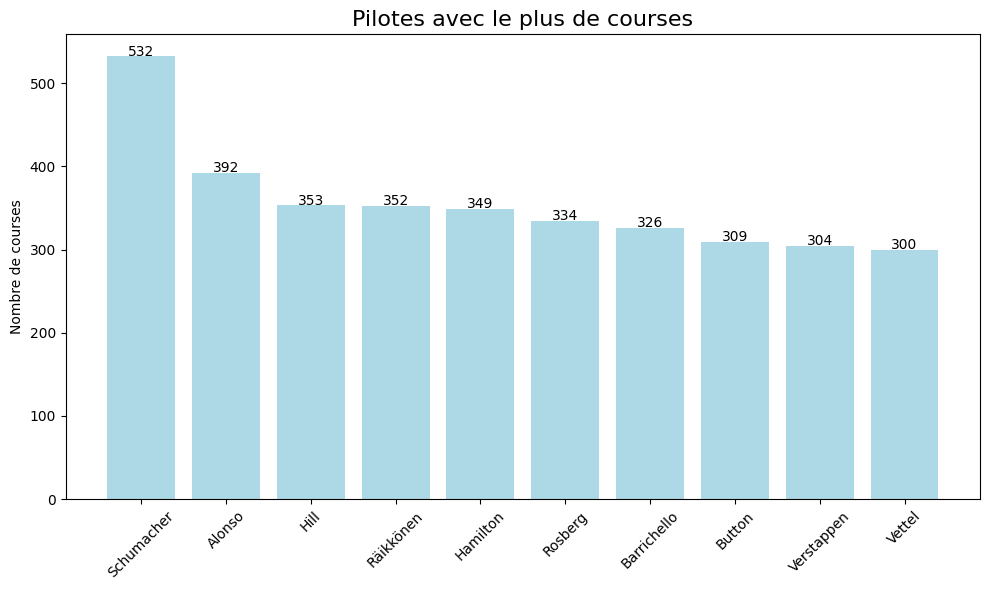

Pilote le plus actif : Schumacher avec 532 courses

TOP 5 POINTS :
1. Hamilton: 4714 points
2. Vettel: 3098 points
3. Verstappen: 2762 points
4. Alonso: 2304 points
5. Schumacher: 1907 points


In [4]:
pilotes_courses = data['surname'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(pilotes_courses.index, pilotes_courses.values, color='lightblue')
plt.title('Pilotes avec le plus de courses', size=16)
plt.xticks(rotation=45)
plt.ylabel('Nombre de courses')

for i, v in enumerate(pilotes_courses.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

print(f"Pilote le plus actif : {pilotes_courses.index[0]} avec {pilotes_courses.iloc[0]} courses")

points_pilotes = data.groupby('surname')['points'].sum().sort_values(ascending=False).head(5)
print("\nTOP 5 POINTS :")
for i, (pilote, pts) in enumerate(points_pilotes.items(), 1):
    print(f"{i}. {pilote}: {pts:.0f} points")

<h2> Points moyens des pilotes par course

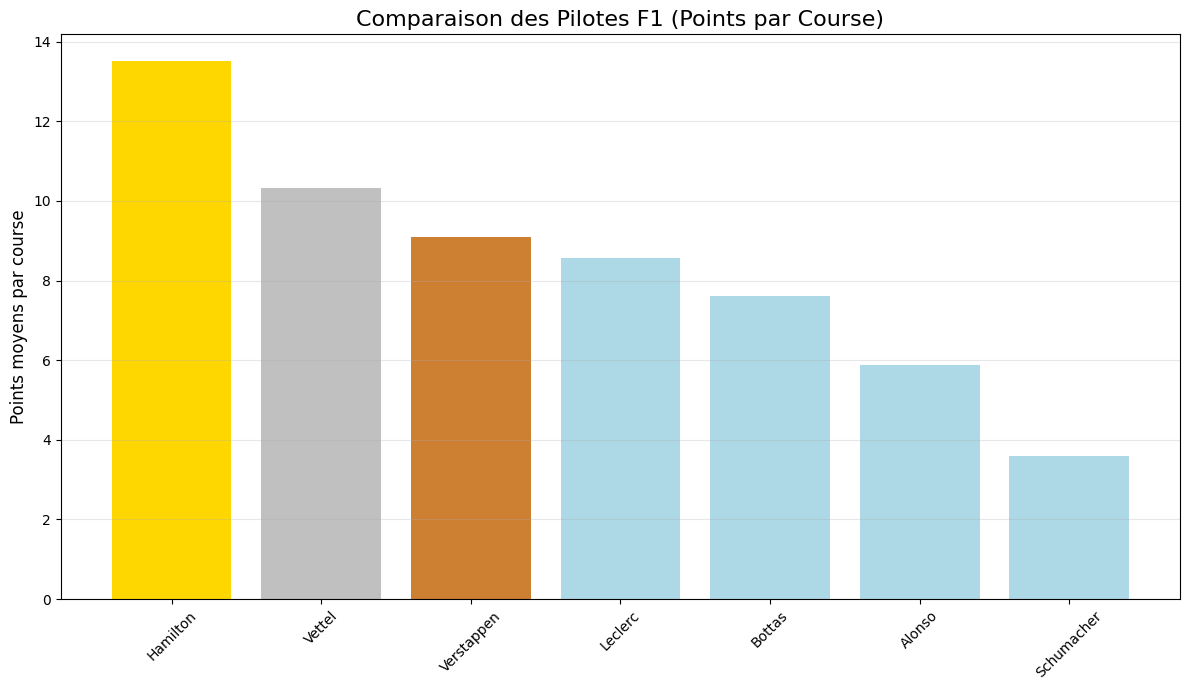

In [5]:
def analyser_pilote_silencieux(nom_pilote):
    pilote_data = data[data['surname'].str.contains(nom_pilote, case=False, na=False)]
    
    if len(pilote_data) == 0:
        return None
    
    courses = len(pilote_data)
    
    points_total = 0
    for _, course in pilote_data.iterrows():
        try:
            pts = course['points']
            if pd.notna(pts) and str(pts) != '\\N':
                points_total += float(pts)
        except:
            pass
    
    points_par_course = points_total / courses if courses > 0 else 0
    
    return points_par_course

pilotes_analyse = []
noms_test = ["Hamilton", "Verstappen", "Schumacher", "Alonso", "Vettel", "Raikkonen", "Bottas", "Leclerc"]

for nom in noms_test:
    moyenne_pts = analyser_pilote_silencieux(nom)
    if moyenne_pts:
        pilotes_analyse.append((nom, moyenne_pts))

pilotes_analyse.sort(key=lambda x: x[1], reverse=True)
pilotes_analyse = pilotes_analyse[:8]

if len(pilotes_analyse) >= 3:
    noms = [p[0] for p in pilotes_analyse]
    scores = [p[1] for p in pilotes_analyse]
    
    plt.figure(figsize=(12, 7))
    colors = ['gold', 'silver', '#CD7F32'] + ['lightblue'] * 5
    
    bars = plt.bar(noms, scores, color=colors[:len(noms)])
    plt.title('Comparaison des Pilotes F1 (Points par Course)', size=16)
    plt.ylabel('Points moyens par course', size=12)
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

<h2> Statistiques d'un pilote au choix + Dashboard

📊 STATS DE HAMILTON
🏁 Total courses : 349
⭐ Points totaux : 4714
💰 Points moyens : 13.5
🥇 Meilleure position : 1
📈 Position moyenne : 3.6


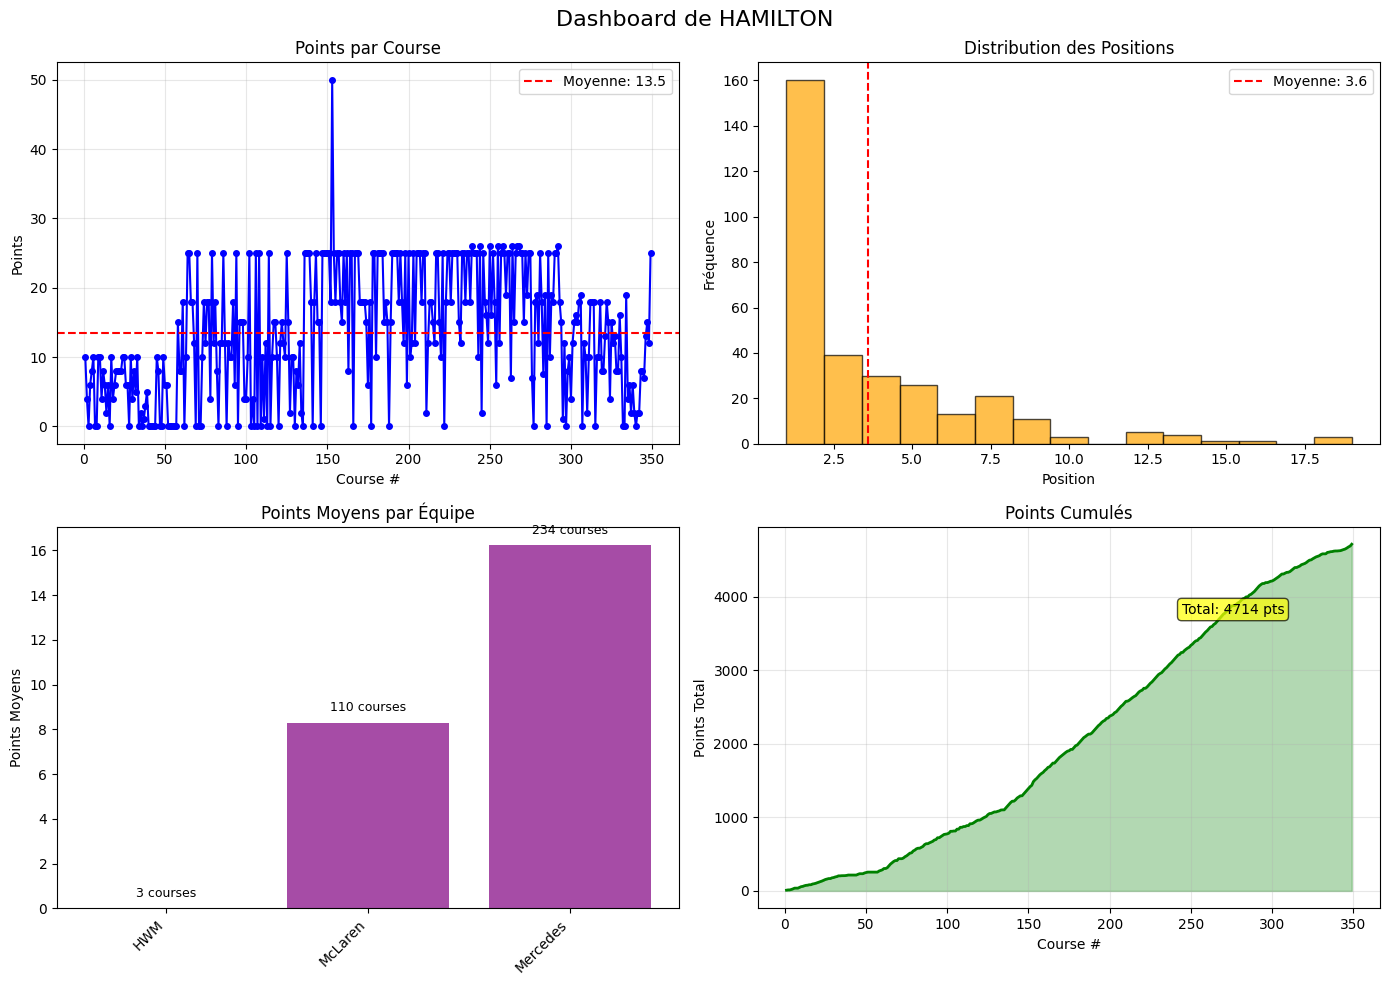


🏆 ÉVALUATION FINALE:
🌟 Évaluation : EXCELLENT pilote !


In [6]:
nom_pilote = "Hamilton"

pilote_data = data[data['surname'].str.contains(nom_pilote, case=False, na=False)]

if len(pilote_data) > 0:
    courses_total = len(pilote_data)
    
    pilote_data_clean = pilote_data.copy()
    pilote_data_clean['points'] = pd.to_numeric(pilote_data_clean['points'], errors='coerce').fillna(0)
    pilote_data_clean['position'] = pd.to_numeric(pilote_data_clean['position'], errors='coerce')
    
    points_total = pilote_data_clean['points'].sum()
    points_moyenne = pilote_data_clean['points'].mean()
    
    positions_valides = pilote_data_clean['position'].dropna()
    
    print(f"📊 STATS DE {nom_pilote.upper()}")
    print(f"🏁 Total courses : {courses_total}")
    print(f"⭐ Points totaux : {points_total:.0f}")
    print(f"💰 Points moyens : {points_moyenne:.1f}")
    
    if len(positions_valides) > 0:
        meilleure_position = positions_valides.min()
        position_moyenne = positions_valides.mean()
        print(f"🥇 Meilleure position : {meilleure_position:.0f}")
        print(f"📈 Position moyenne : {position_moyenne:.1f}")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Dashboard de {nom_pilote.upper()}', size=16)
    
    points_courses = pilote_data_clean['points'].reset_index(drop=True)
    axes[0,0].plot(range(1, len(points_courses)+1), points_courses, 'b-o', markersize=4)
    axes[0,0].set_title('Points par Course')
    axes[0,0].set_xlabel('Course #')
    axes[0,0].set_ylabel('Points')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].axhline(y=points_moyenne, color='red', linestyle='--', label=f'Moyenne: {points_moyenne:.1f}')
    axes[0,0].legend()
    
    if len(positions_valides) > 0:
        axes[0,1].hist(positions_valides, bins=15, color='orange', alpha=0.7, edgecolor='black')
        axes[0,1].set_title('Distribution des Positions')
        axes[0,1].set_xlabel('Position')
        axes[0,1].set_ylabel('Fréquence')
        axes[0,1].axvline(x=position_moyenne, color='red', linestyle='--', label=f'Moyenne: {position_moyenne:.1f}')
        axes[0,1].legend()
    else:
        axes[0,1].hist(pilote_data_clean['points'], bins=10, color='green', alpha=0.7)
        axes[0,1].set_title('Distribution des Points')
        axes[0,1].set_xlabel('Points')
    
    perf_equipes = pilote_data_clean.groupby('team')['points'].agg(['sum', 'mean', 'count'])
    perf_equipes = perf_equipes[perf_equipes['count'] >= 3]
    
    if len(perf_equipes) > 0:
        axes[1,0].bar(range(len(perf_equipes)), perf_equipes['mean'], color='purple', alpha=0.7)
        axes[1,0].set_title('Points Moyens par Équipe')
        axes[1,0].set_ylabel('Points Moyens')
        axes[1,0].set_xticks(range(len(perf_equipes)))
        axes[1,0].set_xticklabels(perf_equipes.index, rotation=45, ha='right')
        
        for i, (idx, row) in enumerate(perf_equipes.iterrows()):
            axes[1,0].text(i, row['mean'] + 0.5, f"{int(row['count'])} courses", ha='center', fontsize=9)
    else:
        axes[1,0].text(0.5, 0.5, 'Pas assez de données\npar équipe', ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('🏗️ Performance par Équipe')
    
    points_cumules = pilote_data_clean['points'].cumsum()
    axes[1,1].plot(range(1, len(points_cumules)+1), points_cumules, 'g-', linewidth=2)
    axes[1,1].fill_between(range(1, len(points_cumules)+1), points_cumules, alpha=0.3, color='green')
    axes[1,1].set_title('Points Cumulés')
    axes[1,1].set_xlabel('Course #')
    axes[1,1].set_ylabel('Points Total')
    axes[1,1].grid(True, alpha=0.3)
    
    axes[1,1].text(len(points_cumules)*0.7, points_cumules.iloc[-1]*0.8, 
                   f'Total: {points_total:.0f} pts', 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    print("\n🏆 ÉVALUATION FINALE:")
    if len(positions_valides) > 0:
        if position_moyenne <= 5:
            print("🌟 Évaluation : EXCELLENT pilote !")
        elif position_moyenne <= 10:
            print("👍 Évaluation : BON pilote")
        else:
            print("😐 Évaluation : Pilote moyen")
    else:
        if points_moyenne >= 10:
            print("🌟 Évaluation : EXCELLENT pilote !")
        elif points_moyenne >= 3:
            print("👍 Évaluation : BON pilote")
        else:
            print("😐 Évaluation : Pilote moyen")
            
else:
    print(f"❌ {nom_pilote} non trouvé")
    pilotes_dispo = data['surname'].value_counts().head().index.tolist()
    print("Pilotes disponibles :", pilotes_dispo)


<h2> Nombre de points des équipes par année

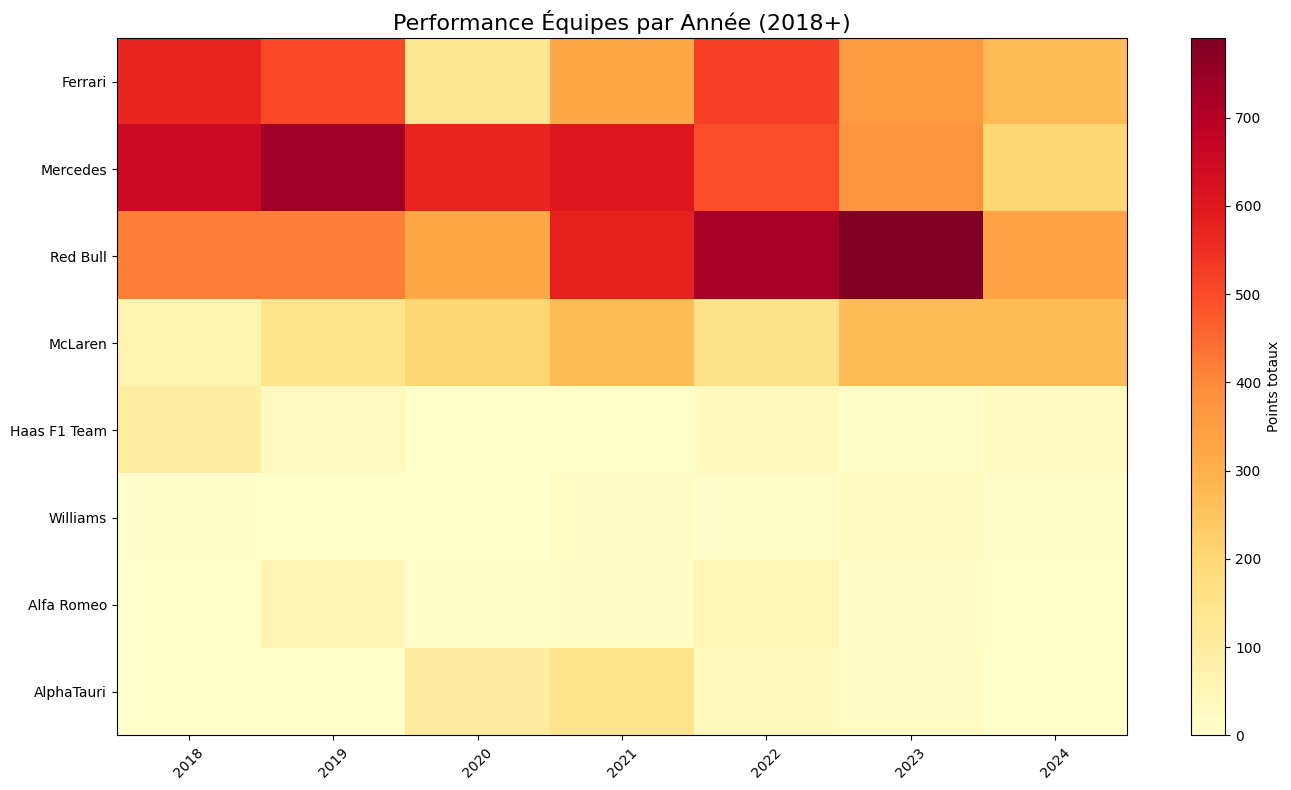

In [7]:
recent_years = data[data['year'] >= 2018]
top_teams = recent_years['team'].value_counts().head(8).index

heatmap_data = []
years = sorted(recent_years['year'].unique())

for team in top_teams:
    team_points = []
    for year in years:
        points = recent_years[(recent_years['team'] == team) & 
                             (recent_years['year'] == year)]['points'].sum()
        team_points.append(points)
    heatmap_data.append(team_points)

plt.figure(figsize=(14, 8))
plt.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Points totaux')

plt.title('Performance Équipes par Année (2018+)', size=16)
plt.xticks(range(len(years)), years, rotation=45)
plt.yticks(range(len(top_teams)), top_teams)

plt.tight_layout()
plt.show()

C:\Users\U1\AppData\Local\Temp\ipykernel_22464\802941170.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=points_data,


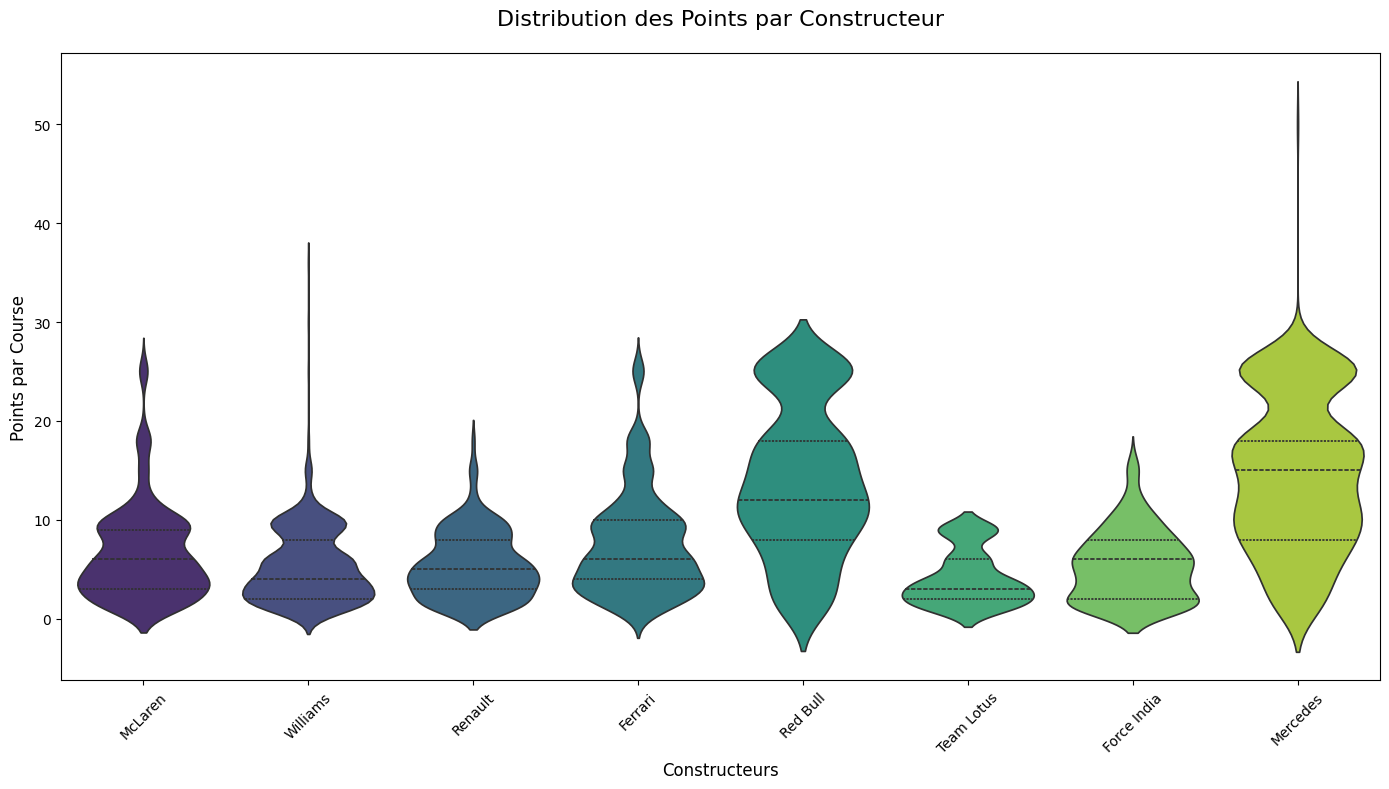

In [21]:
points_constructors = data[data['points'] > 0].copy()
top_point_constructors = points_constructors.groupby('team')['points'].sum().nlargest(8).index
points_data = points_constructors[points_constructors['team'].isin(top_point_constructors)]

if len(points_data) > 50:
    plt.figure(figsize=(14, 8))
    
    try:
        sns.violinplot(data=points_data,
                       x='team',
                       y='points',
                       palette='viridis',
                       inner='quartile')
        
        plt.title('Distribution des Points par Constructeur', size=16, pad=20)
        plt.xlabel('Constructeurs', size=12)
        plt.ylabel('Points par Course', size=12)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        moyennes_points = points_data.groupby('team')['points'].mean().sort_values(ascending=False)
        
    except:
        print(f"Pas assez de données avec points ({len(points_data)} courses)")


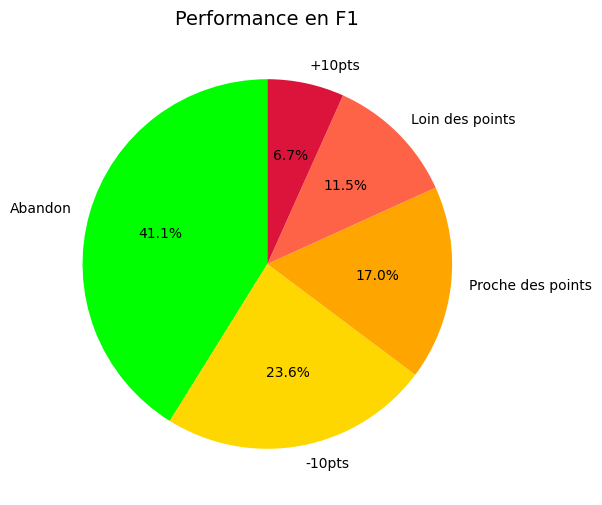

In [31]:
data_clean = data.copy()
data_clean['points'] = pd.to_numeric(data_clean['points'], errors='coerce').fillna(0)
data_clean['position'] = pd.to_numeric(data_clean['position'], errors='coerce')

def perf_simple(points, position):
    if points >= 10: return '+10pts'
    elif points >= 1: return '-10pts'
    elif pd.notna(position) and position <= 12: return 'Proche des points'
    elif pd.notna(position): return 'Loin des points'
    else: return 'Abandon'

data_clean['perf'] = data_clean.apply(lambda x: perf_simple(x['points'], x['position']), axis=1)

perf_counts = data_clean['perf'].value_counts()
colors = ['#00FF00', '#FFD700', '#FFA500', '#FF6347', '#DC143C']

plt.figure(figsize=(8, 6))
plt.pie(perf_counts.values, labels=perf_counts.index, autopct='%1.1f%%', 
        colors=colors[:len(perf_counts)], startangle=90)
plt.title('Performance en F1', size=14)
plt.show()
